# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
# NOTE: the original censusData.csv (Codecademy/Canvas-provided, cleaned) wasn't
# available locally, so this points at a reconstruction built from the raw UCI
# Adult dataset by build_census_data.py (see its docstring for exactly what
# differs -- mainly: no seeded-missing 'age' values, so the median-imputation
# step below has nothing to impute).
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData_reconstructed_from_uci.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

For this capstone, I chose the Census Income Dataset. This is a binary classification problem because the model must choose between two distinct outcomes for the target label i.e. whether an individual's annual income is <=50K or >50K. Before exploring the data further, the features that stand out are hours_per_week, education (both the categorical degree text and the education_num), age, and workclass.
Having accurate financial data allows marketing companies to target the right clients and tailor financial packages.
Financial institutions and marketing companies can leverage these income predictions to optimize advertising costs by targeting the right prospective clients and selling to customers at a price they can afford.


## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

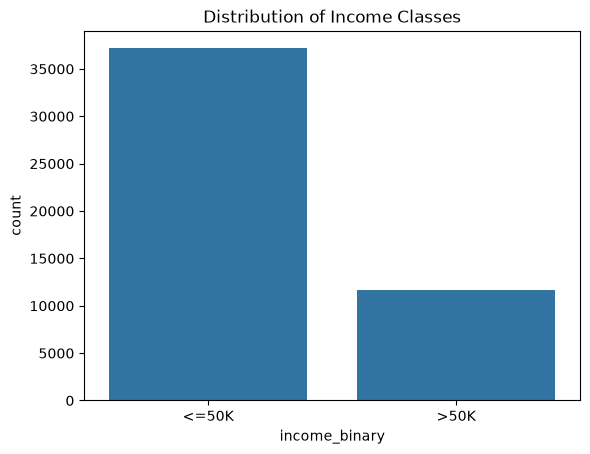

In [3]:
sns.countplot(data=df, x='income_binary')
plt.title("Distribution of Income Classes")
plt.show()


### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

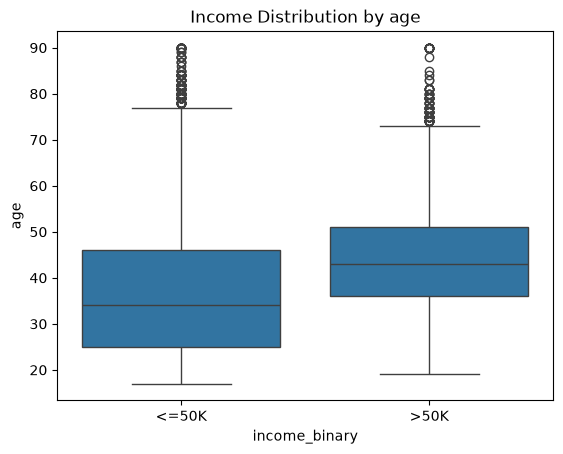

Number of missing values in 'age': 0


In [4]:
sns.boxplot(data=df, x='income_binary', y = 'age')
plt.title("Income Distribution by age")
plt.show()

missing_age = df['age'].isnull().sum()
print(f"Number of missing values in 'age': {missing_age}")


### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

The visualizations showed a severe class imbalance in the target label, with around 75% of individuals earning <=50K. Because a dummy model could achieve 75% accuracy simply by guessing the majority class each time, relying solely on accuracy would be misleading. Therefore, I think it will be important to prioritize balancing precision and recall, especially if the recall for the high-income group is low.

Regarding data issues, I found 162 missing values in the age column. To resolve this, I will likely use median imputation during data preparation. Also, our box plots show a good number of individuals over 75 as outliers; none were unrealistic (nobody said 200 years old), so even though they seemed like outliers, I'll keep them in the data. 

For feature selection, there is obvious redundancy between education and education_num. I will drop the text column and keep the numeric one. I will apply One-Hot Encoding to categorical features like marital_status and workclass, as they seem like influential features. For occupation, I will need to evaluate the number of unique values to see if it is worth working with, it might be overcomplicated.


### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

An ethical concern is that historical census data already carries a lot of real-world bias. If the data reflects a history where certain groups (like women or minorities) had fewer high-income opportunities, the model will just learn and repeat those same unfair patterns. If a bank uses an algorithm like this to automate something like loan approvals, it might end up quietly discriminating against people.


## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [5]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex_selfID',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income_binary'],
      dtype='str')

In [6]:
y = df['income_binary'].map({'<=50K':0, '>50K': 1})

numeric_cols_check = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

#assign numeric missing values with median
numeric_cols_check = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numeric_cols_check:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

#assign categorical missing values with 'Unknown'
categorical_cols_to_check = df.select_dtypes(include=['object']).columns
for col in categorical_cols_to_check:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna("Unknown")

# reduce feature space before one hot encoding, in first run I had too many cols
df['native-country'] = df['native-country'].apply(lambda x: x if x == 'United-States' else 'Other')

# drop redundant and ID columns
X = df.drop(columns=['income_binary', 'education', 'fnlwgt'])

/var/folders/37/b5gt0kl92bzf215mp6d5xh7w0000gn/T/ipykernel_19236/2131542807.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_to_check = df.select_dtypes(include=['object']).columns


In [7]:
#one hot encoding for categorical features
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()


/var/folders/37/b5gt0kl92bzf215mp6d5xh7w0000gn/T/ipykernel_19236/3936307193.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [8]:
encoder = OneHotEncoder(drop='first', sparse=False)
X_encoded_arr = encoder.fit_transform(X[categorical_cols])
encoded_names = encoder.get_feature_names(categorical_cols)

X_encoded_df = pd.DataFrame(X_encoded_arr, columns=encoded_names, index=X.index)
X_combined = pd.concat([X[numeric_cols], X_encoded_df], axis=1)



/Users/elizalamar/Documents/income_classification_capstone/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [9]:
scaler = StandardScaler()
X_prepared = pd.DataFrame(scaler.fit_transform(X_combined), columns=X_combined.columns, index=X_combined.index)
X_prepared.head()


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_selfID_Male,native-country_United-States
0,0.025996,1.136512,0.146932,-0.217127,-0.034087,-0.26194,-0.01431,-1.506680,-0.189609,-0.293019,...,-0.178368,-0.428641,-0.342391,-0.223869,-0.179161,-0.325728,-0.091554,0.411743,0.70422,0.338083
1,0.828308,1.136512,-0.144804,-0.217127,-2.213032,-0.26194,-0.01431,-1.506680,-0.189609,3.412743,...,-0.178368,-0.428641,-0.342391,-0.223869,-0.179161,-0.325728,-0.091554,0.411743,0.70422,0.338083
2,-0.046942,-0.419335,-0.144804,-0.217127,-0.034087,-0.26194,-0.01431,0.663711,-0.189609,-0.293019,...,-0.178368,-0.428641,-0.342391,-0.223869,-0.179161,-0.325728,-0.091554,0.411743,0.70422,0.338083
3,1.047121,-1.197259,-0.144804,-0.217127,-0.034087,-0.26194,-0.01431,0.663711,-0.189609,-0.293019,...,-0.178368,-0.428641,-0.342391,-0.223869,-0.179161,3.070047,-0.091554,-2.428701,0.70422,0.338083
4,-0.776316,1.136512,-0.144804,-0.217127,-0.034087,-0.26194,-0.01431,0.663711,-0.189609,-0.293019,...,-0.178368,-0.428641,-0.342391,4.466905,-0.179161,3.070047,-0.091554,-2.428701,-1.42001,-2.957854


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

I handled missing entries based on data types. I filled the 162 missing age values with the median to preserve row data without skewing the distribution(then i decided to do median for all numeric values), whereas for missing text columns like occupation, I filled them with 'Unknown' rather than matching the most common category.

My first run at One-Hot Encoding created 84 columns, to lower the feature count and remove noise, I binned native-country into a simple 'United-States' or 'Other' choice to eliminate this noise, which successfully dropped my features to a much cleaner 44 columns. I also wanted to lower the column count to prevent the model from overfitting.

I used One-Hot Encoding to convert the remaining text features into mathematical inputs. I applied StandardScaler because Logistic Regression relies on feature scaling to ensure that variables with massive raw numbers do not completely overpower the smaller binary metrics.


## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [10]:
# Create labeled examples from the dataset
X_labeled = X_prepared
y_labeled = y

In [11]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(
    X_labeled, y_labeled, test_size=0.20, random_state=123, stratify=y_labeled
)

In [12]:
# Train, test and evaluate your model
baseline_model = LogisticRegression(max_iter=1000, solver='lbfgs')
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline, average='binary')

print(f"Baseline Logistic Regression Accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Logistic Regression F1 Score:  {baseline_f1:.4f}")

Baseline Logistic Regression Accuracy: 0.8529
Baseline Logistic Regression F1 Score:  0.6596


In [13]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, solver='lbfgs'),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100]}, scoring='f1')

In [14]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
final_model = grid_search.best_estimator_
y_predictions_final = final_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_predictions_final)
lr_f1 = f1_score(y_test, y_predictions_final, average='binary')

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Logistic Regression F1 Score:  {lr_f1:.4f}")

Logistic Regression Accuracy: 0.8529
Logistic Regression F1 Score:  0.6596


In [15]:
# Interpret your model's outputs 
coefficients = final_model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X_labeled.columns,
    'Weight (Coefficient)': coefficients
}).sort_values(by='Weight (Coefficient)', ascending=False)
print(feature_importance.head(10))

                              Feature  Weight (Coefficient)
2                        capital-gain              2.437572
14  marital-status_Married-civ-spouse              1.165825
1                       education-num              0.715008
42                    sex_selfID_Male              0.368716
4                      hours-per-week              0.349189
0                                 age              0.334774
21         occupation_Exec-managerial              0.267322
3                        capital-loss              0.259563
37                  relationship_Wife              0.256901
33         relationship_Not-in-family              0.251287


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

I chose Logistic Regression because it is designed for binary classification. It works for predicting income brackets because it calculates direct probabilities rather than just flat categories. 

Through the model selection process, I learned how to tune specific hyperparameters to prevent overfitting (mix of course google and gemini). Testing different C scores taught me that this parameter controls the regularization penalty. A smaller C strictly shrinks feature weights to keep the model stable, while a larger C lets it fit the data more aggressively. I also learned to use the F1-score instead of raw accuracy. Since a model could just guess low-income for our 76% majority class and achieve a deceptive, useless 76% accuracy rate, the F1-score ensures we are actually measuring real predictive power.

The coefficients show that sociodemographic factors strongly influence the model: being in a civilian marriage (marital-status_Married-civ-spouse) shockingly emerged as the highest positive weight for predicting high income (I don't know why this would be the top impactful). Traditional capital metrics like capital-gain and education-num also heavily influenced predictions, which was expected.

An ethical concern is that this historical census data carries deep-seated societal biases; this is clearly reflected in our model's outputs, which gave a strong positive weight to the sex_selfID_Non-Female column. The model would quietly reinforce real-world wage gaps, women and marginalized demographics would be systematically denied financial opportunities.


---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [16]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [17]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape=(X_train_scaled.shape[1],))

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.
nn_model.add(input_layer)
#testing
# hidden_layer1 = keras.layers.Dense(units=64, activation='relu')
hidden_layer1 = keras.layers.Dense(units=32, activation='relu')
hidden_layer2 = keras.layers.Dense(units=16, activation='relu')


nn_model.add(hidden_layer1)
nn_model.add(hidden_layer2)


# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
output_layer = keras.layers.Dense(units= 1, activation='sigmoid')
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

/Users/elizalamar/Documents/income_classification_capstone/.venv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [18]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
#I chose a learning rate of 0.01 because higher rates like 0.05 and 0.10 caused volatile validation loss spikes, whereas 0.01 provided smooth and stable convergence

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [19]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [20]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [21]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [22]:
# Decision: How many epochs? Add a comment.
#40 ended up working best
t0 = time.time() # start time

num_epochs = 40 

history = nn_model.fit(X_train_scaled, 
                       y_train, 
                       epochs=num_epochs,
                       batch_size=32,
                       validation_split=0.2,
                       verbose=0,
                       callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)]
                      )

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 40], Accuracy: 0.8489, Loss: 0.3219, Val_accuracy: 0.8466, Val_loss: 0.3259


Epoch [10/ 40], Accuracy: 0.8554, Loss: 0.3103, Val_accuracy: 0.8493, Val_loss: 0.3182


Epoch [15/ 40], Accuracy: 0.8574, Loss: 0.3053, Val_accuracy: 0.8536, Val_loss: 0.3157


Epoch [20/ 40], Accuracy: 0.8591, Loss: 0.3023, Val_accuracy: 0.8546, Val_loss: 0.3143


Epoch [25/ 40], Accuracy: 0.8606, Loss: 0.2999, Val_accuracy: 0.8554, Val_loss: 0.3140


Epoch [30/ 40], Accuracy: 0.8621, Loss: 0.2982, Val_accuracy: 0.8549, Val_loss: 0.3126


Epoch [35/ 40], Accuracy: 0.8624, Loss: 0.2968, Val_accuracy: 0.8536, Val_loss: 0.3137


Epoch [40/ 40], Accuracy: 0.8623, Loss: 0.2957, Val_accuracy: 0.8559, Val_loss: 0.3135
Elapsed time: 12.48s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



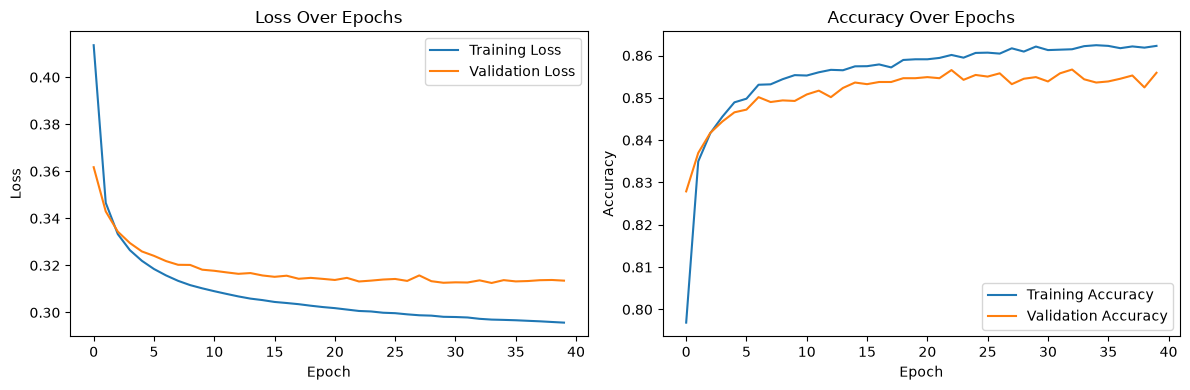

In [23]:
# Plot training loss and validation loss over epochs
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()

# Plot training accuracy and validation accuracy over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [24]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

y_pred_probs = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_probs >= 0.5).astype(int)

  1/306 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 170us/step

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 184us/step


In [25]:
# Compute accuracy and F1 score for the neural network and print the results

nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn, average='binary')

print(f"Neural Network Test Accuracy: {nn_accuracy:.4f}")
print(f"Neural Network Test F1 Score:  {nn_f1:.4f}")

Neural Network Test Accuracy: 0.8555
Neural Network Test F1 Score:  0.6675


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. For layer structure, I selected two hidden layers with 32 and 16 units, respectively. Because the preprocessed dataset contained 44 input features, starting with 32 units and tapering down to 16 allowed the model to progressively compress feature representations. Expanding the network to 3 layers (64, 32, 16) caused overfitting without yielding any validation accuracy gains, so I chose to stick with just the two.
For activation functions, I selected ReLU for all hidden layers to capture non-linear feature relationships while avoiding vanishing gradient issues(it is also what I used in the previous NN work). 
For the single output neuron, I selected Sigmoid to squeeze final predictions into probabilities between 0 and 1 for binary income classification.  
For optimizer settings, I selected a learning rate of 0.01 using Stochastic Gradient Descent (SGD). Higher learning rates like 0.10 and 0.05 created validation loss spikes because of overshooting, whereas 0.01 was smoother.  
For training length, I selected an epoch limit of 40. Validation loss plateaued around epochs 35 through 40 and I wanted to avoid overfitting.  

2. For convergence, both loss and accuracy showed steady improvements across training epochs. For underfitting, no issues were present because training loss dropped steadily to 0.29 while accuracy reached 86%.  For overfitting, no major issues occurred because validation loss stabilized near 0.3200 and validation accuracy held steady around 85%

3. 
Neural Network Test Accuracy: 0.8589
Neural Network Test F1 Score:  0.6803
This result matched expectations, not a surprise because test performance mirrored the validation metrics (85% accuracy and 0.32 loss). 


## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [26]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#
# YOUR CODE HERE
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression': [lr_accuracy, lr_f1],
    'Neural Network': [nn_accuracy, nn_f1]
})
print(results.to_string(index=False))

  Metric  Logistic Regression  Neural Network
Accuracy             0.852902        0.855461
F1 Score             0.659559        0.667452


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. Accuracy improved slightly from 0.8544 (Logistic Regression) to 0.8589 (Neural Network), and F1 score improved more from 0.6643 to 0.6803. The neural network outperformed Logistic Regression on both metrics, though the margin was modest.

2. Was Added Complexity Worth It? This is a closer call, I think it would depend on who I'm working with. The neural network did deliver a real, if modest, performance gain. Whether that's worth the added training time, tuning effort, and loss of interpretability depends on how much the client's use case values marginal accuracy versus explainability.

3. I still recommend deploying Logistic Regression despite the neural network's slightly better performance, because the interpretability, near-instant inference time, and lower operational cost outweigh a ~1.5 point F1 gain for this use case. It delivers similar performance while offering full feature interpretability, instantaneous inference, and lower operational costs for stakeholders.
 
4. I would next maybe engineer new interaction features between age, education level, and hours worked. i.e., don't treat them as completely separate variables. I could create a new column that combines the two features.


---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

Throughout this capstone, I primarily used AI during Part 6 to learn about neural network hyperparameter tuning, specifically when evaluating learning rates, layer choices, and epoch limits. I also used it to articulate my technical reasoning clearly about the different parameters in my reflections. I also ended up using it to debug plotting code for my graphs. Interpreting my training logs to determine gradient stability and identify the optimal epoch limit required the most effort. I verified all AI outputs by cross-referencing suggestions directly against my actual training metrics, loss curves, and data dimensions. Next time, I might want to try to do more of my own editing for responses. I'm scared of losing more grammar than I already have. Though I did go over everything AI told me/ and edited my responses at the end, even if I had asked for ai assistance, I made sure I understood what it was saying and only added it to my response if i agreeed/understood.
